#### Imports

In [9]:
from pathlib import Path
import time
import statistics
import cv2
import matplotlib.pyplot as plt
import pandas as pd

cv2.setNumThreads(1)

In [10]:
IMG_SIZE = (512, 512)
RUNS = 10

In [11]:
INPUT_DIR = "data/chest_xray"   # später anpassen
OUTPUT_DIR = "output/sequential"
RESULTS_CSV = "results/sequential.csv"

#### 1. Get Images

In [12]:
def get_images(folder, n):
    files = []
    for ext in ("*.jpg", "*.jpeg", "*.png"):
        files.extend(Path(folder).rglob(ext))
    return sorted(files)[:n]

#### 2. Process Image

In [13]:
def process_image(img_path):
    # 1. Bild laden + Graustufen
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return False

    # 2. Resize
    img = cv2.resize(img, IMG_SIZE)

    # 3. Median-Filter
    img = cv2.medianBlur(img, 5)

    # 4. CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)

    # 5. Gauß-Filter
    img = cv2.GaussianBlur(img, (3, 3), 0)

    # 6. Histogramm berechnen
    hist = cv2.calcHist([img], [0], None, [256], [0, 256])

    return True

#### 3. Run 

In [14]:
def run_baseline(input_dir, image_count):
    files = get_images(input_dir, image_count)

    start = time.perf_counter()

    processed = 0
    for f in files:
        if process_image(f):
            processed += 1

    runtime = time.perf_counter() - start
    throughput = processed / runtime

    return runtime, throughput, processed

#### 10 Runs per Image

In [15]:
def benchmark():
    image_counts = [100, 500, 1000, 5000]
    rows = []

    for n in image_counts:
        runtimes = []
        throughputs = []

        for run in range(RUNS):
            runtime, throughput, processed = run_baseline(INPUT_DIR, n)
            runtimes.append(runtime)
            throughputs.append(throughput)

        median_runtime = statistics.median(runtimes)
        median_throughput = statistics.median(throughputs)

        rows.append({
            "Variante": "Sequenziell",
            "Bilder": n,
            "Prozesse": 1,
            "Laufzeit in s": round(median_runtime, 3),
            "Speedup": 1.00,
            "Efficiency": 1.00,
            "Throughput": round(median_throughput, 2)
        })

    return pd.DataFrame(rows)

In [16]:
df_seq = benchmark()
df_seq

,Variante,Bilder,Prozesse,Laufzeit in s,Speedup,Efficiency,Throughput
0,Sequenziell,100,1,0.696,1.0,1.0,143.61
1,Sequenziell,500,1,3.538,1.0,1.0,141.32
2,Sequenziell,1000,1,7.112,1.0,1.0,140.61
3,Sequenziell,5000,1,38.539,1.0,1.0,129.74


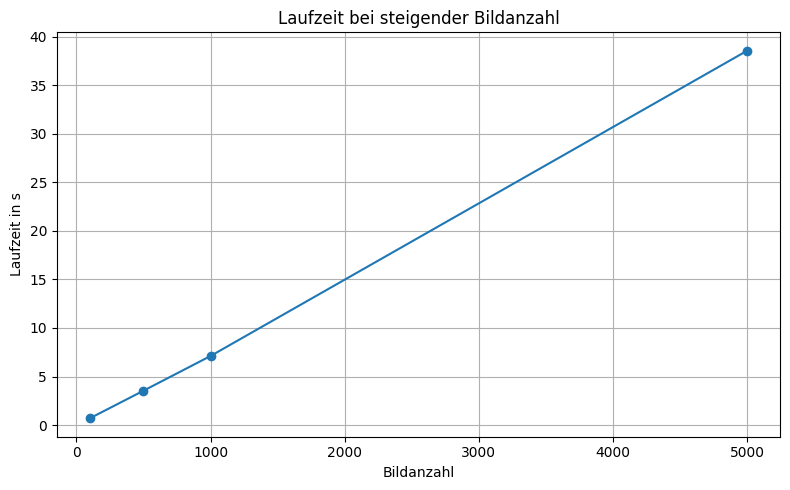

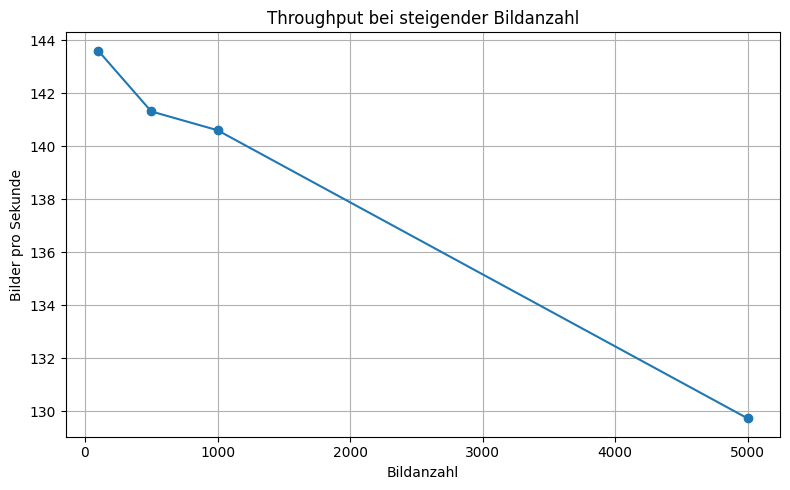

In [17]:
import matplotlib.pyplot as plt
from pathlib import Path

Path("plots").mkdir(exist_ok=True)

# 1. Laufzeit
plt.figure(figsize=(8, 5))
plt.plot(df_seq["Bilder"], df_seq["Laufzeit in s"], marker="o")
plt.xlabel("Bildanzahl")
plt.ylabel("Laufzeit in s")
plt.title("Laufzeit bei steigender Bildanzahl")
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/baseline_runtime.png", dpi=200)
plt.show()

# 2. Throughput
plt.figure(figsize=(8, 5))
plt.plot(df_seq["Bilder"], df_seq["Throughput"], marker="o")
plt.xlabel("Bildanzahl")
plt.ylabel("Bilder pro Sekunde")
plt.title("Throughput bei steigender Bildanzahl")
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/baseline_throughput.png", dpi=200)
plt.show()